In [1]:
import torch
import torch.distributed as dist
import torch.nn as nn
import torch.optim as optim
from torch.nn.parallel import DistributedDataParallel as DDP
import sys, os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
import torch.multiprocessing as mp
import torchvision
import torchvision.transforms as transforms
from torch.nn.parallel import DistributedDataParallel
from torch.utils.data import Dataset
import torch.optim as optim
import pickle as pk
from model_enc_dec_v2 import *
import numpy as np
import h5py as h5
import torch
from torch.nn import functional as F
from dataclasses import dataclass
from contextlib import nullcontext
from dataclasses import dataclass
from torch.nn.parallel import DistributedDataParallel as DDP
from multiprocessing import Pool
import ast

import argparse
import os
import shutil
import numpy as np
import torch

from nvidia.dali.pipeline import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types
from nvidia.dali.plugin.pytorch import DALIGenericIterator, LastBatchPolicy

%load_ext autoreload
%autoreload 2


/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/model_enc_dec_v2.py:415: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast()


In [2]:
def get_sim_number(filepath):
    filename = os.path.basename(filepath)
    number_part = filename.split('_')[-1]
    number = int(number_part.split('.')[0])
    return number

params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))

class ExternalInputIterator:
    def __init__(self, input_dir, label_dir, batch_size, shard_id, num_shards, shuffle=False):
        files_in_inp_dir = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.npy')]
        self.dm_fields_files = sorted(files_in_inp_dir, key=get_sim_number)
        files_in_label_dir = [os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith('.npy')]
        self.gal_prop_files = sorted(files_in_label_dir, key=get_sim_number)
        total = len(self.dm_fields_files)
        print(total, len(self.gal_prop_files))
        assert total == len(self.gal_prop_files)
        
        # Shard the data: split in round-robin (recommended by DALI)
        self.indices = np.arange(total)[shard_id::num_shards]
        if shuffle:
            np.random.shuffle(self.indices)
        self.data_set_len = len(self.indices)
        self.batch_size = batch_size
    def __iter__(self):
        self.i = 0
        return self
    def __next__(self):
        if self.i >= self.data_set_len:
            self.i = 0
            raise StopIteration
        batch_inputs, batch_labels, batch_params = [], [], []
        for _ in range(self.batch_size):
            if self.i >= self.data_set_len:
                break
            idx = self.indices[self.i]
            batch_inputs.append(np.load(self.dm_fields_files[idx]))
            batch_labels.append(np.load(self.gal_prop_files[idx]))
            params = params_all[idx][None,:]
            # print(idx)
            nrep = batch_inputs[-1].shape[0]
            params_rep = np.repeat(params, nrep, axis=0)
            batch_params.append(params_rep)
            self.i += 1
        return (batch_inputs, batch_labels, batch_params)
    @property
    def size(self):
        return self.data_set_len

def create_dali_pipeline(input_dir, label_dir, batch_size, num_threads, device_id, shard_id, num_shards, shuffle=False):
    eii = ExternalInputIterator(input_dir, label_dir, batch_size, shard_id, num_shards, shuffle=shuffle)
    @pipeline_def(batch_size=batch_size, num_threads=num_threads, device_id=device_id)
    def npy_pipeline():
        dmo_fields, gal_tokens, params_rep = fn.external_source(source=eii, num_outputs=3)
        return dmo_fields.gpu(), gal_tokens.gpu(), params_rep.gpu()
    pipe = npy_pipeline()
    pipe.build()
    return pipe, eii.size



In [3]:
grid_sbox = 16
add_space_token = False
subsel_type = 'all'
learning_rate = 2e-4
max_iters = 200
n_embd = 192
patch_size = 2
loss_type = 'cross_entropy'
cnn_type = 'vit'



In [4]:
device = 'cuda'
compile = True 
torch.backends.cuda.matmul.allow_tf32 = True 
torch.backends.cudnn.allow_tf32 = True 
device_type = 'cuda'
dtype = 'bfloat16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# dist.init_process_group("nccl")
# print(int(os.environ.get("RANK", 0)), int(os.environ.get("WORLD_SIZE", 1)), int(os.environ.get("LOCAL_RANK", 0)))
# dist.init_process_group("nccl", rank=int(os.environ.get("RANK", 0)), world_size=int(os.environ.get("WORLD_SIZE", 1)), device_id=torch.device(f'cuda:{int(os.environ.get("LOCAL_RANK", 0))}'))
# rank = dist.get_rank()
rank = 0
print(f"Start running basic DDP example on rank {rank}.")
# Ndevices = torch.cuda.device_count()
# Ndevices = 8
# Ndevices = 2

BoxSize = 25.
grid = 8
# grid_sbox = 32
nvocab = 64
nrand_sel_box = 512


nsnaps = 5

Mstar_cut = 9.5
DS_RES_POS_FAC = 1.0

torch.cuda.empty_cache()
device_id = 0


# meta_f = pk.load(open('/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields_ns512/metadata_fields_grid_16_isim_0_nrandsubsel_512_MAS_NGP_nsnaps_5.pkl','rb'))

meta_f = pk.load(open('/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/gal_props_ns512_3prop/metadata_galaxy_props_snap_90_grid_64_isim_0_nrandsubsel_512_nvocab64_spacetoken_False_wSDSS_photometry_velx_Mstarcut_9.5.pkl','rb'))
# nvocab_total = meta_f['nvocab_total'][()]
start_token = meta_f['start_token']
pad_token = int(meta_f['pad_token'])
end_token = meta_f['end_token']
nvocab_total = end_token + 1
max_sentence_length = meta_f['max_sentence_length']


n_head = 8
n_layer = 4

dropout = 0.2
nparams = 6 # number of parameters in camels to append to the CNN features output
vocab_size = nvocab_total
block_size = max_sentence_length - 1
print(f"block_size = {block_size}, vocab_size = {vocab_size}, pad_token = {pad_token}, max_sentence_length = {max_sentence_length}")
print(f"nembd = {n_embd}, nhead = {n_head}, nlayer = {n_layer}, nparams = {nparams}, dropout = {dropout}")

# if grid_sbox == 32:
#     layers_types =  ['res', 'res', 'res', 'res']
# if grid_sbox == 16:
#     layers_types =  ['res', 'res', 'res']
# if grid_sbox == 8:
#     layers_types =  ['res','res']
if grid_sbox == 32:
    layers_types =  ['res_cbam', 'res_cbam', 'res_cbam', 'res_cbam']
if grid_sbox == 16:
    layers_types =  ['res_cbam', 'res_cbam', 'res_cbam']
if grid_sbox == 8:
    layers_types =  ['res_cbam']    

if cnn_type == 'res_cbam':
    dmo_cond_embed_type = 'resnet'
    layers_types =  ['res_cbam']
elif cnn_type == 'vit':
    dmo_cond_embed_type = 'vit'
    layers_types =  ['cnn']
elif cnn_type == 'vit_cbam':
    dmo_cond_embed_type = 'vit'
    layers_types =  ['res_cbam']        
else:
    print(f"Invalid cnn_type: {cnn_type}")
    

layers_types =  ['cnn']            
HaloConfig = {'block_size': block_size, 'vocab_size': vocab_size, 'n_layer': n_layer, 
                'n_head': n_head, 'n_embd': n_embd, 'nparams': nparams, 'dropout': dropout, 
                'bias': False, 'ksize': 3, 'density_grid_in': grid_sbox, 'density_grid_out': 4, 
                'ninp_density': 30, 'pad_token': pad_token, 'flash': True,
                'dmo_cond_embed_type':dmo_cond_embed_type, 'layers_types':layers_types,
                # 'n_layers_vit': 4, 'n_heads_vit': 8}
                # 'n_layers_vit': n_layer, 'n_heads_vit': n_head}
                'patch_size':patch_size,
                'n_layers_vit': 4, 'n_heads_vit': 8}
                # 'n_layers_vit': 3, 'n_heads_vit': 8}
                # 'n_layers_vit': 4, 'n_heads_vit': 4}


model = HaloDecoderModel(HaloConfig).to(device_id)
# load the model checkpoint:

# cp_name = f'/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/quijote_halos/FINAL4_fidfinetune_TEST_model_hres_encdec_ddp_grid_8_nvocab_64_nembed_256_nhead_8_nrandsubsel_8192_subselDMOfields_all_Mstarcut_12.7_spacetoken_False_maxiter_1500_lr_0.0005.pt'
# checkpoint = torch.load(cp_name, map_location=f'cuda:{device_id}')    
# model.load_state_dict(checkpoint['model'])

if rank == 0: print(f"Init model and loaded to GPU", flush=True)            
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

# model = DDP(model, device_ids=[device_id])




Start running basic DDP example on rank 0.


block_size = 145, vocab_size = 69, pad_token = 67, max_sentence_length = 146
nembd = 192, nhead = 8, nlayer = 4, nparams = 6, dropout = 0.2
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
number of parameters: 3.60M
Init model and loaded to GPU


In [5]:
# meta_f.keys()


In [6]:
# global_batch_size
learning_rate = 1e-3
best_loss = 1e20


In [ ]:
def cosine_lr(step, total_steps, lr_min, lr_max):
    import math
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * step / total_steps))

nepochs = 50

for jepoch in range(nepochs):
    print(jepoch)
    # input_dir, label_dir = args['input_dir'], args['label_dir']
    # batch_size = args['batch_size']
    input_dir = '/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields_ns512'
    label_dir = '/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/gal_props_ns512_3prop'
    batch_size = 16
    pipeline, n_samples_per_rank = create_dali_pipeline(
        input_dir, label_dir, batch_size, num_threads=4, device_id=0,
        shard_id=0, num_shards=1, shuffle=False)
    dali_iterator = DALIGenericIterator(
        [pipeline],
        ['DM_fields', 'gal_tokens', 'params'],
        last_batch_policy=LastBatchPolicy.PARTIAL,
        auto_reset=True,
    )
    
    args = {'num_examples': 1000, 'lr_min': 1e-6, 'lr_max': learning_rate/((1 + jepoch)**0.75), 'batch_size': batch_size}
    # batch_size = 2
    global_batch_size = batch_size * 1
    total_batches = int(np.ceil(args['num_examples'] / global_batch_size))
    lr_min = args['lr_min']
    lr_max = args['lr_max']
    # Each process will see total_batches_per_rank batches (they all are equal or off by 1)
    batches_seen = 0
    
    sub_batch_size = 512
    nsub_batches = int(np.ceil(global_batch_size * 512 / sub_batch_size))
    # shuffle_sub_batches = False
    shuffle_sub_batches = True
    print(nsub_batches)
    for step, batch in enumerate(dali_iterator):
        data_batch = batch[0]
        DM = torch.flatten(data_batch['DM_fields'], start_dim=0, end_dim=1)
        DM = torch.moveaxis(DM, -1, 1)  # move the last dimension to the second position

        gal_tokens = torch.flatten(data_batch['gal_tokens'], start_dim=0, end_dim=1)
        X = gal_tokens[:, :-1].to(torch.long)
        Y = gal_tokens[:, 1:].to(torch.long)
        mask = torch.logical_not(X != pad_token)
        masked_logits = torch.zeros(mask.shape, device=X.device, dtype=torch.float32)
        MASK = masked_logits.masked_fill(mask, float('-inf'))[:,None,:]

        PARAMS = data_batch['params'].to(torch.float32)
        PARAMS = torch.flatten(PARAMS, start_dim=0, end_dim=1)

        global_step = step  # local across this rank, but all ranks have unique data; global batches is fine

        # Compute global batch for LR schedule (all GPUs see different batches)
        # For one-epoch run: global_step = (local_rank) * local_batches_sofar + step
        lr = cosine_lr(global_step, total_batches-1, lr_min, lr_max)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        loss_mean_here = 0
        loss_all_array = []
        all_inds = np.arange(X.shape[0])
        if shuffle_sub_batches:
            np.random.shuffle(all_inds)
        for js in range(nsub_batches-1):
            model.require_backward_grad_sync = (js == nsub_batches - 1)
            ind_js = all_inds[js*sub_batch_size:(js+1)*sub_batch_size]
            # if step >= 60:
                # print(js, len(ind_js))
            try:
                with ctx:
                    _, loss = model(X[ind_js], DM[ind_js], 
                                params=PARAMS[ind_js], maskd=MASK[ind_js], 
                                targets=Y[ind_js], loss_type=loss_type)
                scaler.scale(loss).backward()   
            except:
                pass
            loss_mean_here += loss.item()
            loss_all_array.append(loss.item())
        # loss_mean_here /= nsub_batches
        loss_all_array = np.array(loss_all_array)
        loss_max_here = np.max(loss_all_array)
        loss_min_here = np.min(loss_all_array)
        loss_mean_here = np.mean(loss_all_array)

        # optimizer.step()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        # torch.cuda.empty_cache()

        # if dist.get_rank() == 0:
        # print(f"[GPU {0} step {global_step+1}/{total_batches}] LR: {lr:.6f} | Loss: {loss.item():.4f}")

        if np.mod(step + 1, 10) == 0:
            print(f"[GPU {0} step {global_step+1}/{total_batches}] LR: {lr:.6f} | loss mean: {loss_mean_here:.4f}, loss min: {loss_min_here:.4f}, loss max: {loss_max_here:.4f}")

        batches_seen += 1
        if batches_seen >= total_batches:
            break  # Make sure you go through all samples ONCE, globally

        # if loss is less than previous best, save the checkpoint:
        if loss_mean_here < best_loss:
            best_loss = loss_mean_here
            checkpoint = {
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scaler': scaler.state_dict(),
                'global_step': global_step,
                'loss': best_loss,
            }
            torch.save(checkpoint, f'/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/tmp/v3_checkpoint_step_{step*(jepoch+1)}.pt')
            print(f"Checkpoint saved at step {global_step} with loss mean {best_loss:.4f}, loss min: {loss_min_here:.4f}, loss max: {loss_max_here:.4f}")

        # termination conditions
        # if iter_num > max_iters:
        #     break




0
1000 1000
16
Checkpoint saved at step 0 with loss mean 4.3057, loss min: 4.2878, loss max: 4.3204
Checkpoint saved at step 1 with loss mean 3.6408, loss min: 3.5003, loss max: 3.7462
Checkpoint saved at step 3 with loss mean 3.5612, loss min: 3.4375, loss max: 3.6910
Checkpoint saved at step 5 with loss mean 3.4559, loss min: 3.3494, loss max: 3.6732
Checkpoint saved at step 6 with loss mean 3.2994, loss min: 3.0877, loss max: 3.4677
[GPU 0 step 10/63] LR: 0.000949 | loss mean: 3.1094, loss min: 2.8322, loss max: 3.3371
Checkpoint saved at step 9 with loss mean 3.1094, loss min: 2.8322, loss max: 3.3371
[GPU 0 step 20/63] LR: 0.000786 | loss mean: 3.3816, loss min: 3.1959, loss max: 3.5530
Checkpoint saved at step 23 with loss mean 2.9646, loss min: 2.7653, loss max: 3.2377
[GPU 0 step 30/63] LR: 0.000551 | loss mean: 3.1691, loss min: 2.9121, loss max: 3.3168
[GPU 0 step 40/63] LR: 0.000304 | loss mean: 3.3166, loss min: 3.1171, loss max: 3.5051
Checkpoint saved at step 46 with loss

In [33]:
# checkpoint = torch.load('/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/tmp/v2_checkpoint_step_279.pt', map_location='cuda:0')
# checkpoint = torch.load('/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/tmp/v3_checkpoint_step_437.pt', map_location='cuda:0', weights_only=False)
# checkpoint = torch.load('/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/tmp/v5_checkpoint_step_198.pt', map_location='cuda:0', weights_only=False)
checkpoint = torch.load('/projects/bdne/spandey3/FINAL_GOTHAM/GOTHAM/src/tmp/v5_checkpoint_step_151.pt', map_location='cuda:0', weights_only=False)
state_dict = checkpoint['model']
new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
# model.load_state_dict(checkpoint['model'])
model.eval()
print()
model = model.bfloat16()

print(checkpoint['loss'])





2.5044198036193848


In [34]:
isim_infer = 0
input_dir = '/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields_ns512'
label_dir = '/work/nvme/bdne/spandey3/camels_tng/gotham_data/LH/gal_props_ns512_3prop'
dm_fields_file = f'{input_dir}/DMO_fields_isim_{isim_infer}.npy'
gal_prop_file = f'{label_dir}/galaxy_props_isim_{isim_infer}.npy'
DM_val = np.load(dm_fields_file)
DM_val = np.moveaxis(DM_val, -1, 1)
gal_prop_infer = np.load(gal_prop_file)
params_infer = params_all[isim_infer][None,:]
nrep = DM_val.shape[0]
PARAMS = np.repeat(params_infer, nrep, axis=0)

# logits, _ = model(X[ind_js], DM[ind_js], 
#             params=PARAMS[ind_js], maskd=MASK[ind_js], 
#             targets=Y[ind_js], loss_type=loss_type)




In [35]:
# DM_val.shape, PARAMS.shape, gal_prop_infer.shape
# gal_prop_infer.shape


In [36]:
TEMPERATURE = 1.0
dev = torch.device('cuda:0')
nvox_samp = 512
max_new_tokens = max_sentence_length
idx_all = np.ones((nvox_samp, max_new_tokens))
jb = 0
batch_size = 8**3
nvox_per_batch = batch_size
idx_inp = torch.zeros((nvox_per_batch, 1), dtype=torch.long, device=dev)
DM_val_jb = torch.tensor(DM_val[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...], device=dev).to(torch.float16)
param_jb = torch.tensor(PARAMS[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...], device=dev).to(torch.float16)
new_samples_jb = np.ones((nvox_per_batch, max_new_tokens))
ind_jb = np.arange(nvox_per_batch)
new_samples_jb[:, 0] = idx_inp[:,0].cpu().detach().numpy() + start_token
for jt in range(1, max_new_tokens):
    if len(ind_jb) > 0:
        # crop idx to the last block_size tokens
        idx_cond = torch.tensor(new_samples_jb[ind_jb, :jt], dtype=torch.long, device=dev)
        # get the predictions
        logits, loss = model(idx_cond, DM_val_jb[ind_jb,...], params=param_jb[ind_jb,...])
        # focus only on the last time step
        logits = logits[:, -1, :] # becomes (B, C)
        # apply softmax to get probabilities
        probs = F.softmax(logits/TEMPERATURE, dim=-1) # (B, C)
        # sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1).cpu().detach().numpy() # (B, 1)
        # append sampled index to the running sequence
        # if idx_next == end_token:
            # break
        new_samples_jb[ind_jb, jt] = idx_next[:,0]
        ind_to_del = np.where(idx_next[:,0] == end_token)[0]
        # for jv in range(len(ind_jb)):
            # if idx_next[jv, 0] == end_token:
        if len(ind_to_del) > 0:
            ind_jb = np.delete(ind_jb, ind_to_del)


idx_all[jb*nvox_per_batch:(jb+1)*nvox_per_batch, :] = new_samples_jb



In [37]:
nvocab = 64
grid = 8
# add_space_token = False
BoxSize = 25.
xall = (np.linspace(0, BoxSize/grid, nvocab + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)


prop_min = meta_f['prop_min']
prop_max = meta_f['prop_max']

dim_pos = 3
dim_prop = len(prop_min)   
dim_tot = dim_pos + dim_prop
idx_all_rs = np.reshape(np.array(idx_all), (grid, grid, grid, idx_all.shape[-1])).astype(int)
# pos_infer_all, prop_infer_all = get_prop_pos(idx_all_rs)

# X_val = idx_all_rs
def get_prop_pos(X_val):
    pos_infer_all = []
    prop_infer_all = []

    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                sentence_here = X_val[jx, jy, jz]
                if add_space_token:
                    ntokens_per_halo = dim_tot + 1
                else:
                    ntokens_per_halo = dim_tot
                ind_start_token = np.where(sentence_here == start_token)[0][0]
                if end_token in sentence_here:
                    ind_end_token = np.where((sentence_here == end_token) | (sentence_here == pad_token))[0]
                    try:
                        Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
                    except:
                        print(ind_end_token, ind_start_token, ntokens_per_halo)
                    # print(Nhalos_here)
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        Nhalos_here = ((ind_end_token - ind_start_token ) / ntokens_per_halo)[0]
                        print(Nhalos_here, Nhalos_here, 'Nhalos_here is not an integer')
                        # pass
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        print(Nhalos_here, 'Nhalos_here is not an integer')
                    else:
                        if Nhalos_here > 0:
                            for jh in range(int(Nhalos_here)):
                                try:
                                    prop_all = np.zeros(dim_prop)        
                                    for jp in range(dim_prop):
                                        # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                                        noise_val = 0
                                        bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 1 + jp]
                                        try:
                                            prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                                        except:
                                            pass
                                            # print(sentence_here)
                                    
                                    coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 4]] + (BoxSize/grid)*jx) % BoxSize
                                    coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 5]] + (BoxSize/grid)*jy) % BoxSize
                                    coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 6]] + (BoxSize/grid)*jz) % BoxSize
                                    pos_infer_all.append([coord_x, coord_y, coord_z])  
                                    prop_infer_all.append(prop_all)                                      

                                except Exception as e:
                                    print(e)
                                    pass
                                    # print(sentence_here[ind_start_token], ntokens_per_halo)
                else:           
                    # print('End token not found')
                    pass

    pos_infer_all = np.array(pos_infer_all)
    prop_infer_all = np.array(prop_infer_all)
    return pos_infer_all, prop_infer_all




In [38]:
pos_infer_all, prop_infer_all = get_prop_pos(idx_all_rs)


In [39]:
gal_prop_infer_rs = np.reshape(np.array(gal_prop_infer), (grid, grid, grid, gal_prop_infer.shape[-1])).astype(int)
pos_truth_all, prop_truth_all = get_prop_pos(gal_prop_infer_rs)



In [40]:
pos_truth_all.shape, pos_infer_all.shape




((165, 3), (116, 3))

(0.0, 25.0)

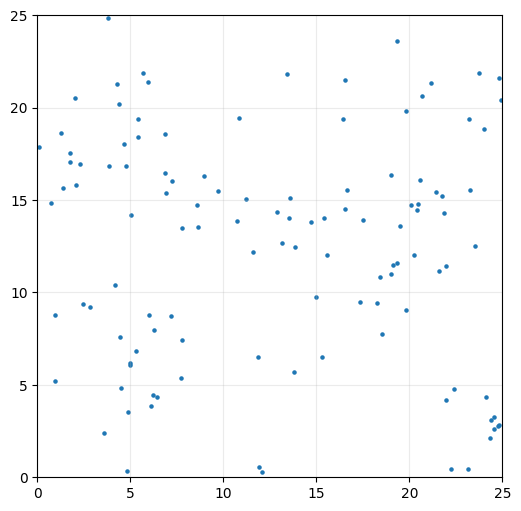

In [41]:
pl.figure(figsize=(6,6))
pl.scatter(pos_infer_all[:,0], pos_infer_all[:,1], s=5)
pl.grid(alpha=0.25)
pl.xlim(0,25)
pl.ylim(0,25)


(0.0, 25.0)

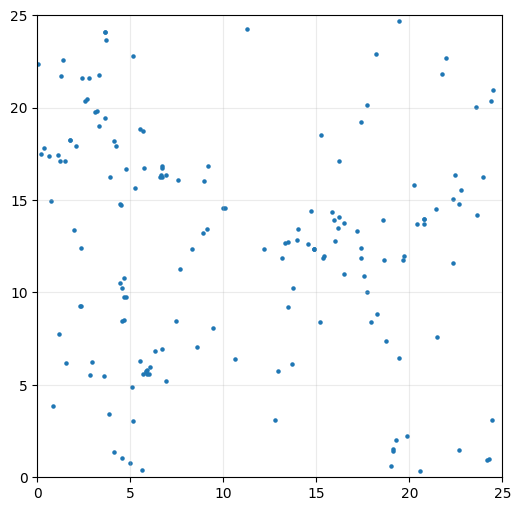

In [42]:
pl.figure(figsize=(6,6))
pl.scatter(pos_truth_all[:,0], pos_truth_all[:,1], s=5)
pl.grid(alpha=0.25)
pl.xlim(0,25)
pl.ylim(0,25)


((165, 3), (84, 3))